In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


원본 데이터 불러오기

In [1]:
import pandas as pd
file_path = "/content/drive/MyDrive/기계학습 11조 프로젝트/cleaned_data.csv"

df = pd.read_csv(file_path)
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/기계학습 11조 프로젝트/cleaned_data.csv'

공항 간 거리 데이터 불러오기

In [2]:
import pandas as pd
file_path = "/content/drive/MyDrive/기계학습 11조 프로젝트/Distance_of_All_Airports_20250523_030226.csv"

df2 = pd.read_csv(file_path)
df2.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/기계학습 11조 프로젝트/Distance_of_All_Airports_20250523_030226.csv'

전처리 완료 데이터 가져오기(직접 실행하면 오래 걸리기 때문에 이미 totalTravelDistance 결측치 제거된 데이터 가져오기)

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/기계학습 11조 프로젝트/filled_totalTravelDistance.csv"

df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821388 entries, 0 to 821387
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   searchDate                    821388 non-null  object 
 1   flightDate                    821388 non-null  object 
 2   startingAirport               821388 non-null  object 
 3   destinationAirport            821388 non-null  object 
 4   travelDuration                821388 non-null  object 
 5   isBasicEconomy                821388 non-null  bool   
 6   isNonStop                     821388 non-null  bool   
 7   baseFare                      821388 non-null  float64
 8   totalFare                     821388 non-null  float64
 9   seatsRemaining                821388 non-null  int64  
 10  totalTravelDistance           821388 non-null  float64
 11  segmentsDepartureTimeRaw      821388 non-null  object 
 12  segmentsArrivalTimeRaw        821388 non-nul

폰트 설치(colab 폰트 설정 때문에 들어간 내용- 안해도 괜찮음)

In [ ]:
# matplotlib의 폰트 캐시 삭제
import matplotlib as mpl
import os

cache_dir = mpl.get_cachedir()
print("캐시 디렉토리:", cache_dir)

# 캐시 파일 강제 삭제
import shutil
shutil.rmtree(cache_dir)


캐시 디렉토리: /root/.cache/matplotlib


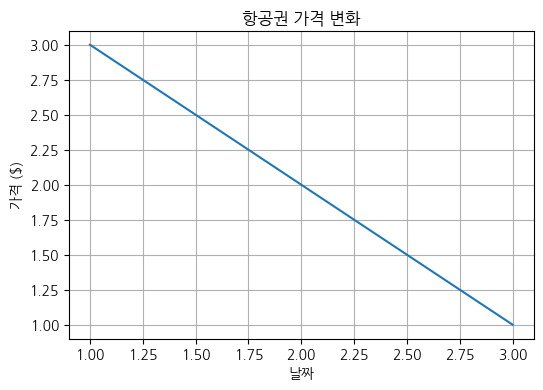

In [ ]:
# 폰트 설치
!apt-get -qq install -y fonts-nanum

# matplotlib 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 테스트
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [3, 2, 1])
plt.title("항공권 가격 변화")
plt.xlabel("날짜")
plt.ylabel("가격 ($)")
plt.grid(True)
plt.show()
#안되면 런타임 재시작후 다시 확인

1. 데이터 확인 절차 및 필요한 외부라이브러리 호출

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from dateutil import parser
from sklearn.impute import SimpleImputer
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")


#plt.rcParams['font.family'] ='NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] =False
df = pd.read_csv("cleaned_data.csv")
# 기본 정보 확인
print(df.shape)
df.info()
df.describe()
df.head()


# 범주형 변수 확인 및 저장을 위한 for문
category_columns = []
for col in df.columns:
    if df[col].dtype =='object' :
        categories = df[col].unique()
        category_columns.append(col)
        print(f'[{col}]({len(categories)})')

(821388, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821388 entries, 0 to 821387
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   searchDate                    821388 non-null  object 
 1   flightDate                    821388 non-null  object 
 2   startingAirport               821388 non-null  object 
 3   destinationAirport            821388 non-null  object 
 4   travelDuration                821388 non-null  object 
 5   isBasicEconomy                821388 non-null  bool   
 6   isNonStop                     821388 non-null  bool   
 7   baseFare                      821388 non-null  float64
 8   totalFare                     821388 non-null  float64
 9   seatsRemaining                821388 non-null  int64  
 10  totalTravelDistance           760389 non-null  float64
 11  segmentsDepartureTimeRaw      821388 non-null  object 
 12  segmentsArrivalTimeRaw        8

In [ ]:
def get_distance(departure, arrival):
    try:
        temp = df2[(df2['ORIGIN'] == departure) & (df2['DEST'] == arrival)]
        if not temp.empty:
            return temp['DISTANCE IN MILES'].iloc[0]
        else:
            return 0  # 또는 None 처리도 가능
    except Exception as e:
        print(f"get_distance 오류 ({departure} → {arrival}): {e}")
        return 0

# totalTravelDistance만 없고 segmentsDistance는 있는 데이터 찾기
missing_S = df[df['totalTravelDistance'].isnull()]
total_rows = len(missing_S)
cnt=0
error_cnt = 0

for idx, row in missing_S.iterrows():
    try:
        total_distance = 0

        dep_list = str(row['segmentsDepartureAirportCode']).split('||')
        arr_list = str(row['segmentsArrivalAirportCode']).split('||')
        travel_spot = dep_list + [arr_list[-1]]  # append → 리스트 연결

        for dep, arr in zip(travel_spot[:-1], travel_spot[1:]):
            dist = get_distance(dep, arr)
            total_distance += dist
            print(f"{cnt}번째 데이터 : {dep} → {arr}: {dist} miles (누적: {total_distance})")
        cnt+=1
        df.at[idx, 'totalTravelDistance'] = total_distance

    except Exception as e:
        print(f"[오류] 인덱스 {idx}: {e}")
        error_cnt += 1
    # 🔄 진행률 표시
    #percent = (i + 1) / total_rows * 100
    #print(f"[{i+1}/{total_rows}] 완료 ({percent:.2f}%)")

print(f"총 실패 건수: {error_cnt}")
# ✅ CSV 저장
output_filename = "filled_totalTravelDistance.csv"
df.to_csv(output_filename, index=False)
print(f"파일이 저장되었습니다: {output_filename}")


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
58369번째 데이터 : MCO → BOS: 1121.0 miles (누적: 2106.0)
58370번째 데이터 : ATL → FLL: 581.0 miles (누적: 581.0)
58370번째 데이터 : FLL → BOS: 1237.0 miles (누적: 1818.0)
58371번째 데이터 : CLT → LAS: 1916.0 miles (누적: 1916.0)
58371번째 데이터 : LAS → OAK: 407.0 miles (누적: 2323.0)
58372번째 데이터 : DEN → AUS: 768.0 miles (누적: 768.0)
58372번째 데이터 : AUS → LAX: 0 miles (누적: 768.0)
58373번째 데이터 : PHL → DFW: 1303.0 miles (누적: 1303.0)
58373번째 데이터 : DFW → LAX: 1235.0 miles (누적: 2538.0)
58374번째 데이터 : LAX → BWI: 2329.0 miles (누적: 2329.0)
58374번째 데이터 : BWI → ATL: 577.0 miles (누적: 2906.0)
58375번째 데이터 : ORD → LAS: 1514.0 miles (누적: 1514.0)
58375번째 데이터 : LAS → LAX: 236.0 miles (누적: 1750.0)
58376번째 데이터 : CLT → FLL: 632.0 miles (누적: 632.0)
58376번째 데이터 : FLL → BOS: 1237.0 miles (누적: 1869.0)
58377번째 데이터 : DTW → ATL: 594.0 miles (누적: 594.0)
58377번째 데이터 : ATL → EWR: 746.0 miles (누적: 1340.0)
58378번째 데이터 : LAX → DTW: 1979.0 miles (누적: 1979.0)
58378번째 데이터 : DTW → ATL: 594.0 miles (누적: 2573.0)
58379번째 데이터 : 

totalTravelDistance 결측치 제거 결과 확인

In [ ]:
print("전체 데이터셋 크기: ",len(df))
temp = df[df['totalTravelDistance'].isnull()]
print("totalTravelDistance 결측치 개수:",len(temp))

전체 데이터셋 크기:  821388
totalTravelDistance 결측치 개수: 0


flightWeekDay 때문에 밑의 코드를 2번 실행함

In [9]:
top5_airlines = df['segmentsAirlineName'].value_counts().head(5).index
sample = df[df['segmentsAirlineName'].isin(top5_airlines)]


# 출발 시간 문자열 → 시(hour) 추출 함수
def extract_hour(x):
    try:
        raw = x.split('||')[0]
        dt = parser.parse(raw)
        return dt.hour
    except:
        return np.nan

def count_stops(x) :
    try :
        return x.count('||')
    except :
        return 0


count    821388.000000
mean          0.827633
std           0.584060
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: stop_count, dtype: float64


In [ ]:
df['departure_hour'] = df['segmentsDepartureTimeRaw'].apply(extract_hour)
# 결측치 제거
df_clean = df.dropna(subset=['departure_hour', 'baseFare']).copy()

# 정수형으로 변환 (boxplot에서 범주 처리 위해서 )
df_clean['departure_hour'] = df_clean['departure_hour'].astype(int)


df['flightDate'] = pd.to_datetime(df['flightDate'])
df['searchDate'] = pd.to_datetime(df['searchDate'])
df['days_before_departure'] = (df['flightDate'] - df['searchDate']).dt.days

df['flightWeekday'] = df['flightDate'].dt.dayofweek

df['departure_hour'] = df['segmentsDepartureTimeRaw'].apply(extract_hour)

df['route'] = df['startingAirport'] + '-' + df['destinationAirport']

top_routes = df['route'].value_counts().head(20).index
sample = df[df['route'].isin(top_routes)]

df['hour_bin'] = pd.cut(df['departure_hour'],
                        bins=[0, 6, 12, 18, 24],
                        labels=['0~6시', '6~12시', '12~18시', '18~24시'],
                        right=False)

# 샘플링 50000개만, 너무 많아서 이렇게 처리만함
sample_df = df_clean.sample(n=50000, random_state=42)


# 만약 sample_df에만 쓰고 싶다면:
sample_df['hour_bin'] = pd.cut(sample_df['departure_hour'],
                               bins=[0, 6, 12, 18, 24],
                               labels=['0~6시', '6~12시', '12~18시', '18~24시'],
                               right=False)

df.drop(columns=['hour_0~6시', 'hour_6~12시', 'hour_12~18시', 'hour_18~24시'], inplace=True)

# 그 다음 다시 수행
df = pd.get_dummies(df, columns=['hour_bin'], prefix='hour')
df.head(5)
df['stop_count'] = df ['segmentsDistance'].apply (count_stops)

top5_airlines = df['segmentsAirlineName'].value_counts().head(5).index
sample = df[df['segmentsAirlineName'].isin(top5_airlines)]



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821388 entries, 0 to 821387
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   searchDate                    821388 non-null  datetime64[ns]
 1   flightDate                    821388 non-null  datetime64[ns]
 2   startingAirport               821388 non-null  object        
 3   destinationAirport            821388 non-null  object        
 4   travelDuration                821388 non-null  object        
 5   isBasicEconomy                821388 non-null  bool          
 6   isNonStop                     821388 non-null  bool          
 7   baseFare                      821388 non-null  float64       
 8   totalFare                     821388 non-null  float64       
 9   seatsRemaining                821388 non-null  int64         
 10  totalTravelDistance           821388 non-null  float64       
 11  segmentsDepar

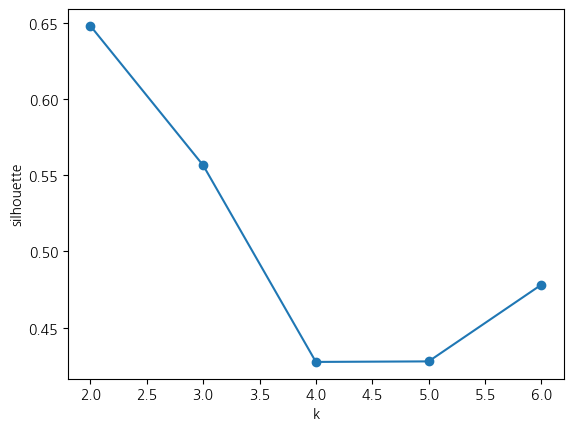

▶ 최적 클러스터 수: 2
airport  cluster
    ATL        0
    BOS        0
    CLT        0
    DFW        0
    EWR        0
    DTW        0
    IAD        0
    JFK        0
    PHL        0
    LGA        0
    MIA        0
    ORD        0
    DEN        1
    LAX        1
    OAK        1
    SFO        1


In [ ]:
cabin_score_map = {
    'basic': 0,
    'coach': 1,
    'premium': 2,
    'business': 3,
    'first': 4
}

def encode_cabin_code(cabin_str):
    try:
        codes = cabin_str.split('||')
        scores = [cabin_score_map.get(code.lower(), np.nan) for code in codes]
        return np.nanmean(scores)  # 평균 점수
    except:
        return np.nan

df['cabin_score'] = df['segmentsCabinCode'].apply(encode_cabin_code)
df.info()
df.head(5)


# 1) 거리 행렬 로드
file_path ="/content/drive/MyDrive/기계학습 11조 프로젝트/공항별 거리.csv"
ref_df = pd.read_csv(file_path, index_col=0)
airports = ['ATL','BOS','CLT','DEN','DFW','DTW','EWR','IAD',
            'JFK','LAX','LGA','MIA','OAK','ORD','PHL','SFO']
dist_df = ref_df.loc[airports, airports].copy()

# 2) 하삼각→상삼각 순으로 NaN 채우기
dist_df = dist_df.T.combine_first(dist_df)

# 3) 대각선 0으로
np.fill_diagonal(dist_df.values, 0)

# 4) 열 평균으로 NaN 대치
imp = SimpleImputer(strategy='mean')
dist_matrix = imp.fit_transform(dist_df.values)

# 5) **대칭 행렬 강제화**
dist_matrix = (dist_matrix + dist_matrix.T) / 2

# 6) MDS 임베딩
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0)
coords = mds.fit_transform(dist_matrix)

# 7) 실루엣 분석으로 최적 k 찾기
ks = range(2,7)
sil_scores = [silhouette_score(coords, KMeans(n_clusters=k, random_state=0).fit_predict(coords)) for k in ks]
plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('silhouette'); plt.show()

best_k = ks[np.argmax(sil_scores)]
print(f"▶ 최적 클러스터 수: {best_k}")

# 8) 최종 클러스터링 결과
labels = KMeans(n_clusters=best_k, random_state=0).fit_predict(coords)
df_clusters = pd.DataFrame({'airport': airports, 'cluster': labels})
print(df_clusters.sort_values('cluster').to_string(index=False))


# 3.유의미한 EDA

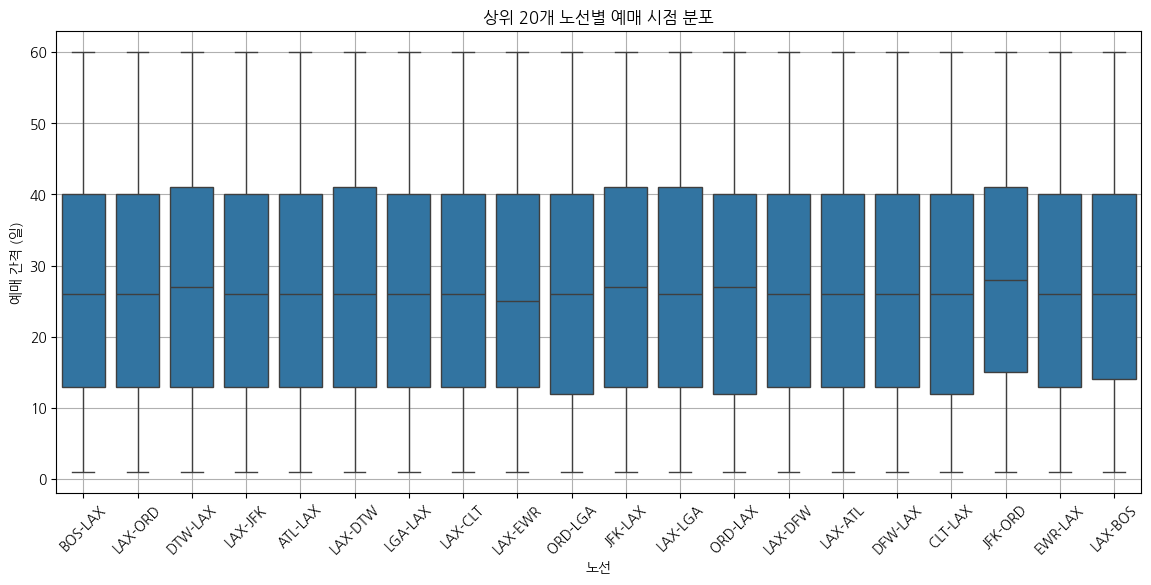

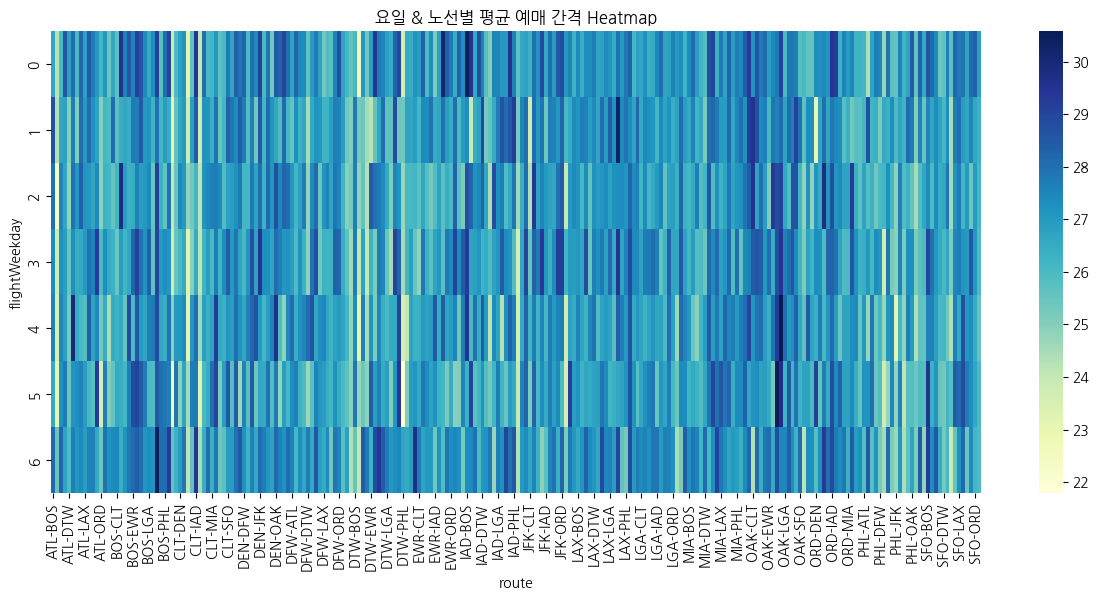

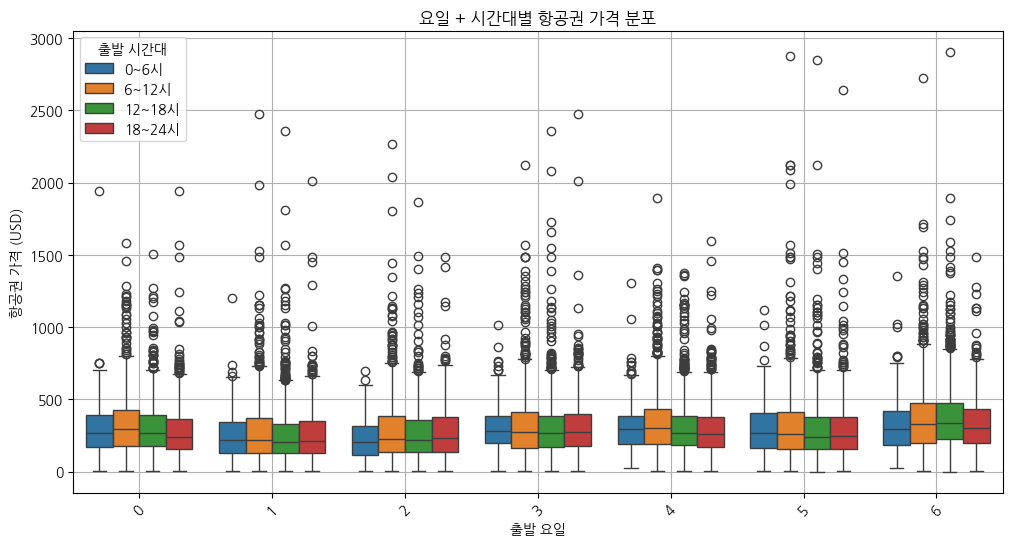

In [ ]:

plt.figure(figsize=(14, 6))
sns.boxplot(x='route', y='days_before_departure', data=sample)
plt.title('상위 20개 노선별 예매 시점 분포')
plt.xlabel('노선')
plt.ylabel('예매 간격 (일)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

pivot = df.pivot_table(index='flightWeekday', columns='route', values='days_before_departure', aggfunc='mean')
plt.figure(figsize=(15, 6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("요일 & 노선별 평균 예매 간격 Heatmap")
plt.show()



plt.figure(figsize=(12, 6))
sns.boxplot(x='flightWeekday', y='baseFare', hue='hour_bin', data=sample_df)   #?? 원래 있던 sample_df는 flightWeekday 열 생성 이전에 샘플링 되어서 flightWeekday 열이 없어서 오류가 남.
plt.title('요일 + 시간대별 항공권 가격 분포')
plt.xlabel('출발 요일')
plt.ylabel('항공권 가격 (USD)')
plt.legend(title='출발 시간대')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

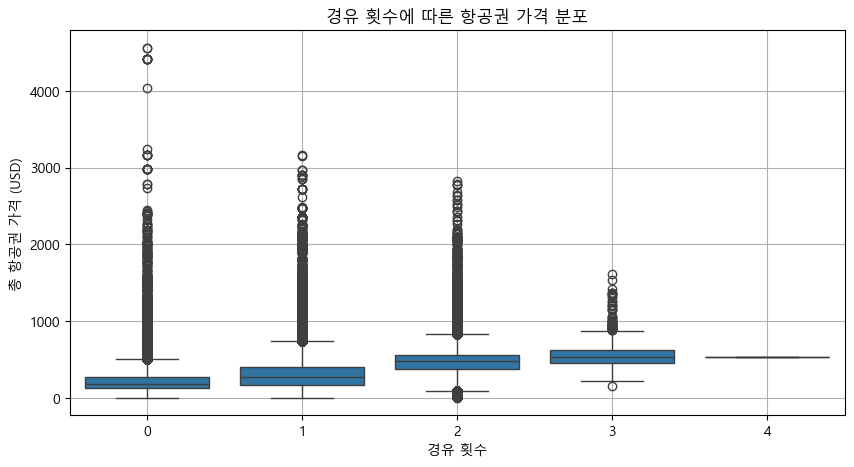

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='stop_count', y='baseFare', data=df)
plt.title('경유 횟수에 따른 항공권 가격 분포')
plt.xlabel('경유 횟수')
plt.ylabel('총 항공권 가격 (USD)')
plt.grid(True)
plt.show()

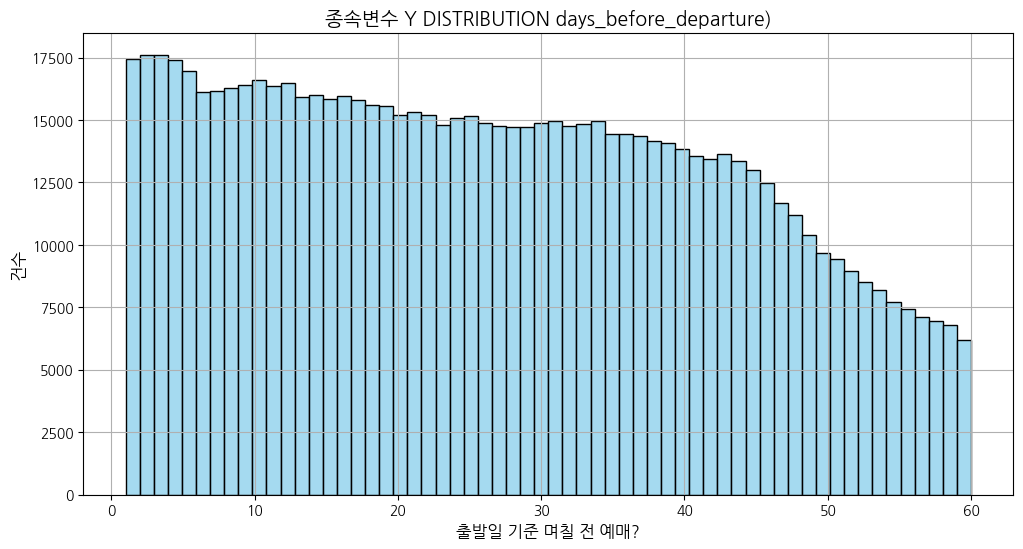

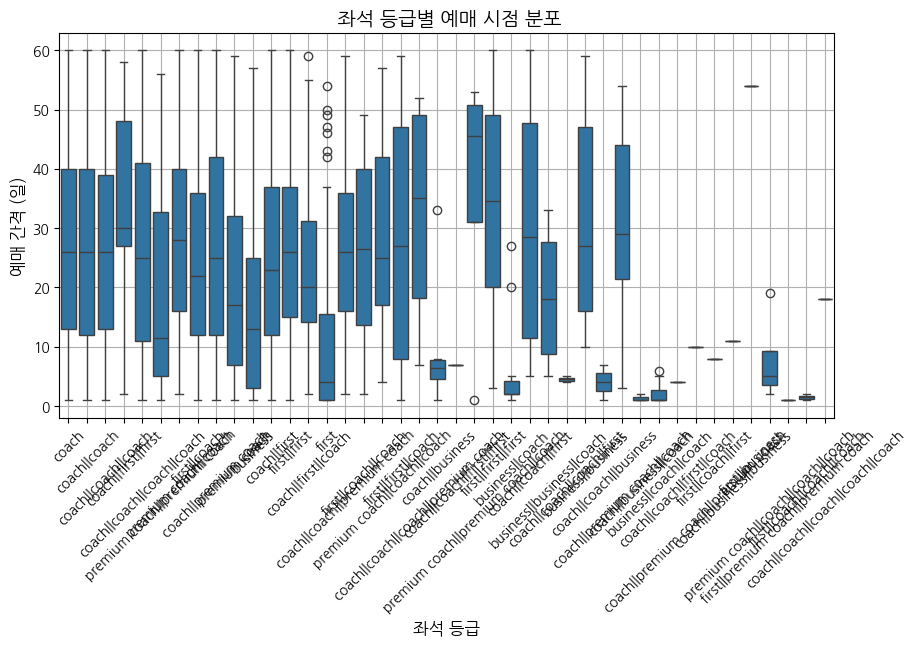

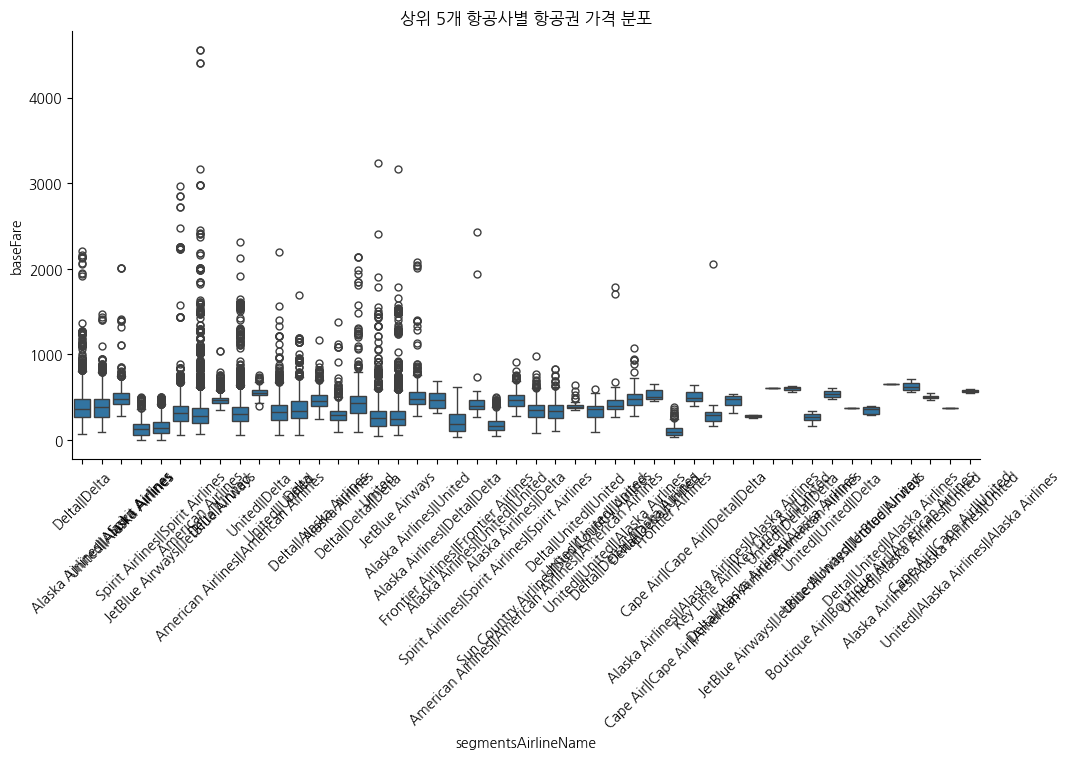

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['days_before_departure'], bins=60, kde=False, color='skyblue', edgecolor='black')
plt.title('종속변수 Y DISTRIBUTION days_before_departure)', fontsize=14)
plt.xlabel('출발일 기준 며칠 전 예매?', fontsize=12)
plt.ylabel('건수', fontsize=12)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='segmentsCabinCode', y='days_before_departure', data=df)
plt.title(' 좌석 등급별 예매 시점 분포', fontsize=14)
plt.xlabel('좌석 등급', fontsize=12)
plt.ylabel('예매 간격 (일)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
sns.catplot(data=sample,
            x='segmentsAirlineName', y='baseFare',
            kind='box', height=5, aspect=2)
plt.xticks(rotation=45)
plt.title("상위 5개 항공사별 항공권 가격 분포")
plt.show()

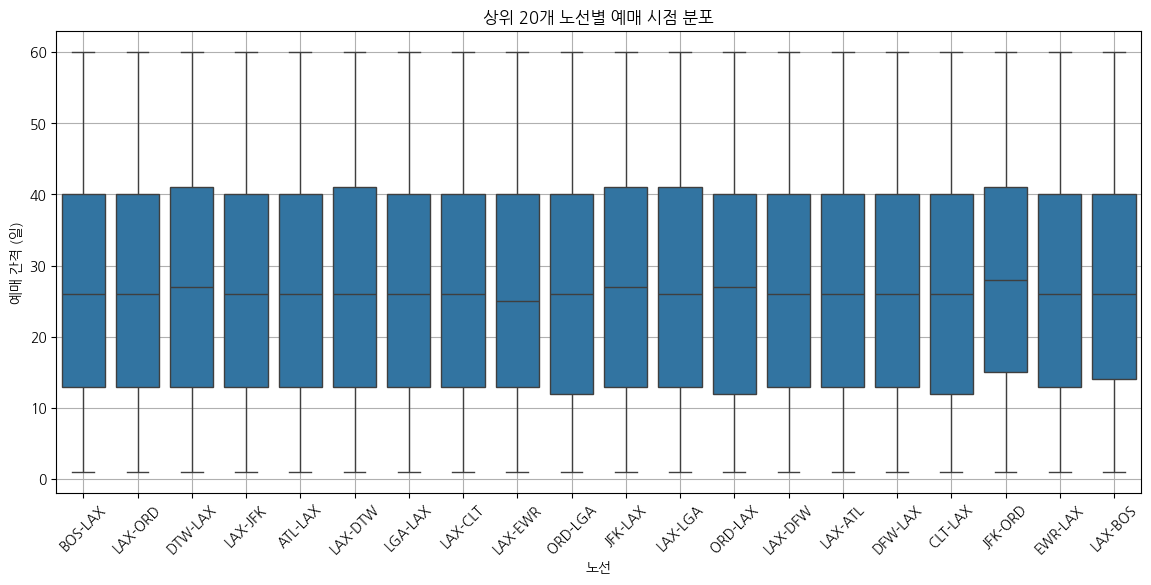

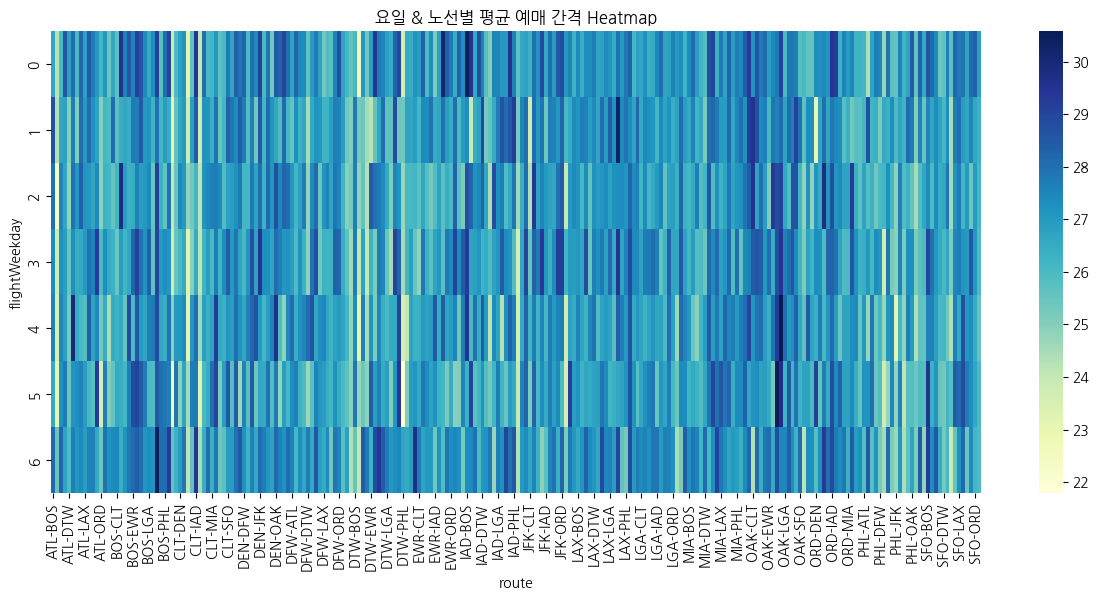

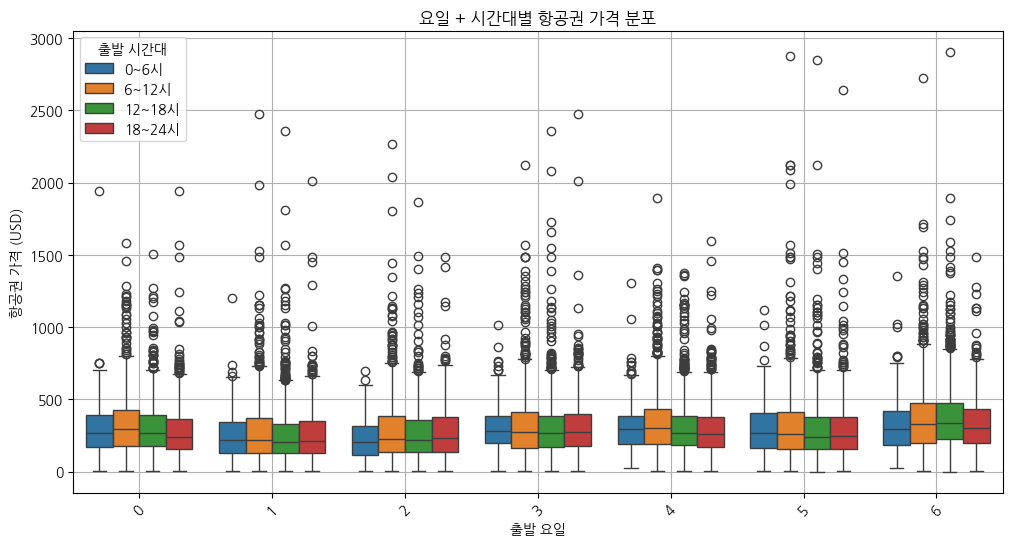

In [ ]:

plt.figure(figsize=(14, 6))
sns.boxplot(x='route', y='days_before_departure', data=sample)
plt.title('상위 20개 노선별 예매 시점 분포')
plt.xlabel('노선')
plt.ylabel('예매 간격 (일)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

pivot = df.pivot_table(index='flightWeekday', columns='route', values='days_before_departure', aggfunc='mean')
plt.figure(figsize=(15, 6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("요일 & 노선별 평균 예매 간격 Heatmap")
plt.show()



plt.figure(figsize=(12, 6))
sns.boxplot(x='flightWeekday', y='baseFare', hue='hour_bin', data=sample_df)
plt.title('요일 + 시간대별 항공권 가격 분포')
plt.xlabel('출발 요일')
plt.ylabel('항공권 가격 (USD)')
plt.legend(title='출발 시간대')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

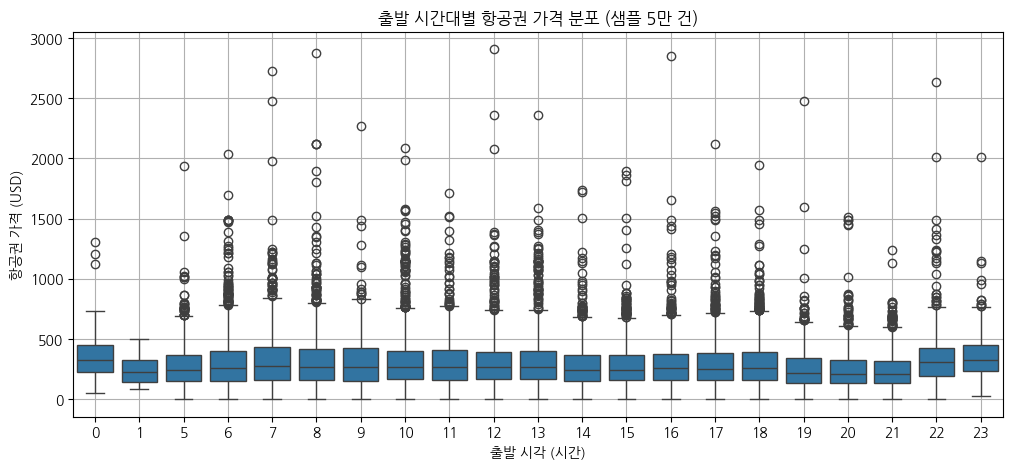

In [ ]:
# 5. 시각화
plt.figure(figsize=(12, 5))
sns.boxplot(x='departure_hour', y='baseFare', data=sample_df)
plt.title('출발 시간대별 항공권 가격 분포 (샘플 5만 건)')
plt.xlabel('출발 시각 (시간)')
plt.ylabel('항공권 가격 (USD)')
plt.grid(True)
plt.show()

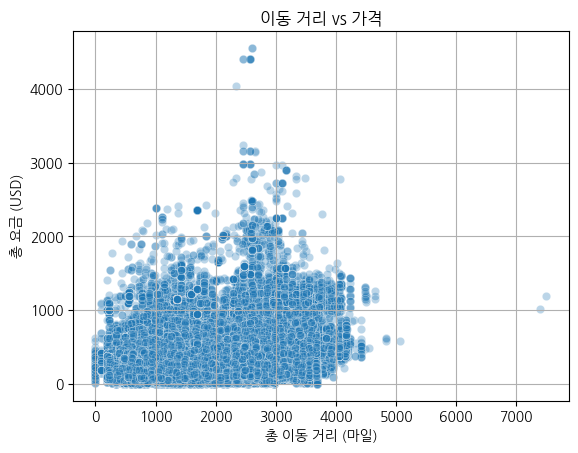

In [ ]:

# 장거리일 수록 비싼게 일반적인데, 노선에 따라서 변동폭이 클지 보기위해
sns.scatterplot(x='totalTravelDistance', y='baseFare', data=df, alpha=0.3)
plt.title('이동 거리 vs 가격')
plt.xlabel('총 이동 거리 (마일)')
plt.ylabel('총 요금 (USD)')
plt.grid(True)
plt.show()

수치형 컬럼 출력 ['baseFare', 'totalFare', 'seatsRemaining', 'totalTravelDistance', 'departure_hour', 'days_before_departure', 'cabin_score']


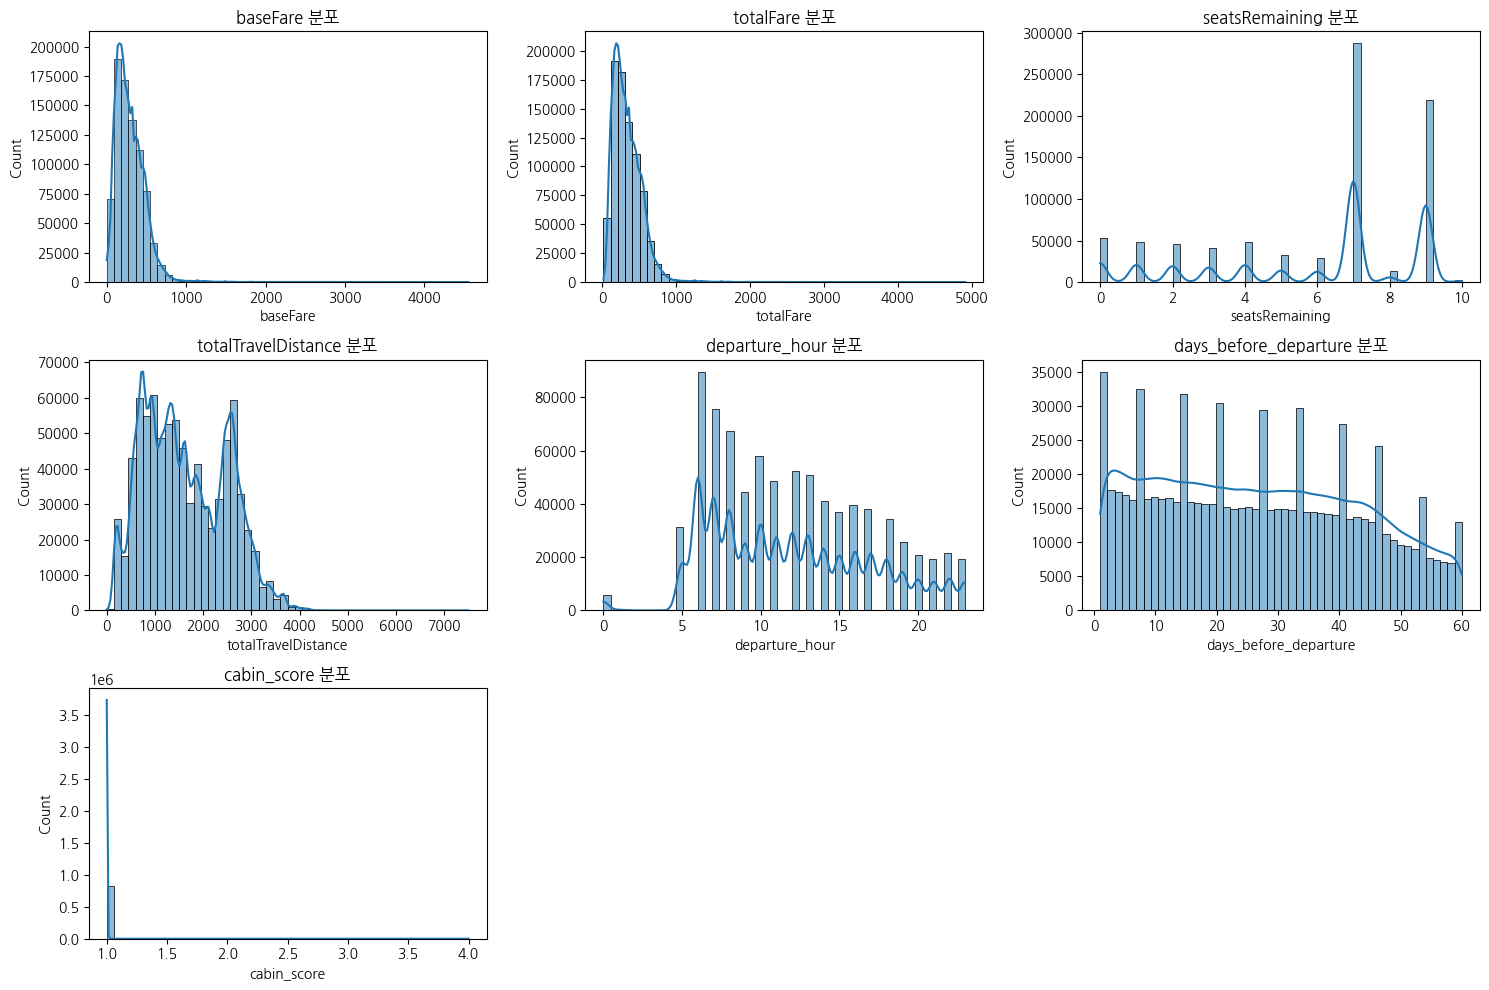

In [ ]:

numerical_columns = df.drop(columns=category_columns).select_dtypes(include=['int64','float64']).columns.tolist()

print('수치형 컬럼 출력', numerical_columns)

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"{col} 분포")
    plt.tight_layout()
plt.show()

In [ ]:
def parse_duration_extended(duration_str):
    if not isinstance(duration_str, str):
        return None

    # 초는 무시
    duration_str = re.sub(r'\d+S', '', duration_str)

    # 정규표현식으로 PnDTnHnM 추출
    pattern = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?'
    match = re.match(pattern, duration_str)
    if match:
        days = int(match.group(1)) if match.group(1) else 0
        hours = int(match.group(2)) if match.group(2) else 0
        minutes = int(match.group(3)) if match.group(3) else 0
        return days * 24 * 60 + hours * 60 + minutes

    return None

# 적용
df['travelDurationMinutes'] = df['travelDuration'].apply(parse_duration_extended)
df['fare_per_minute'] = df['baseFare'] / df['travelDurationMinutes']
df['via_count'] = df['segmentsCabinCode'].apply(lambda x: x.count('||') if isinstance(x, str) else 0)

#first business 제거
df = df[~df['segmentsCabinCode'].str.contains('first|business', na=False, case=False)]
unique_values = df['segmentsCabinCode'].unique()

count = df['segmentsCabinCode'].str.contains('premium', na=False, case=False).sum()
#premium 제거
df_nopremium = df[~df['segmentsCabinCode'].str.contains('premium', na=False, case=False)]
unique_values = df_nopremium['segmentsCabinCode'].unique()

#ATL -> DFW
df_filtered = df_nopremium[(df_nopremium['startingAirport'] == 'ATL') & (df_nopremium['destinationAirport'] == 'DFW')]

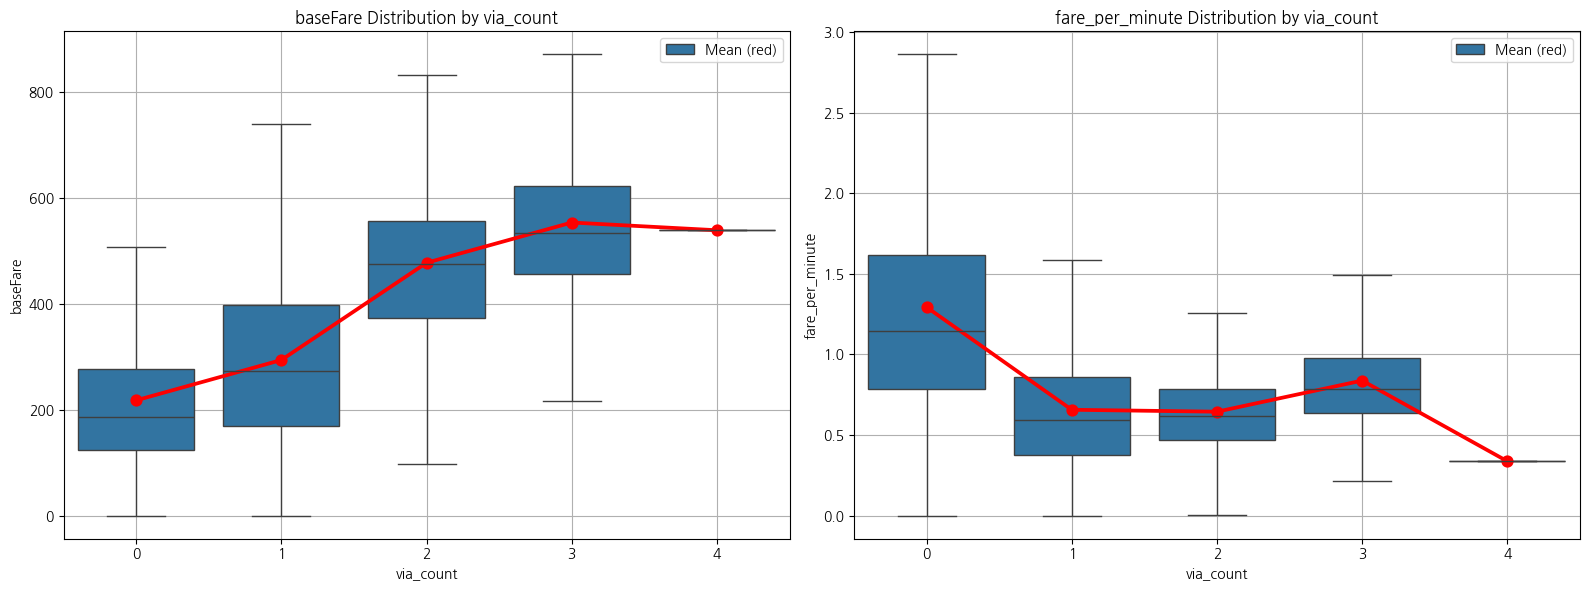

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
# 1. baseFare 그래프
sns.boxplot(x='via_count', y='baseFare', data=df, showfliers=False, ax=axes[0])
sns.pointplot(x='via_count', y='baseFare', data=df, color='red', errorbar=None, ax=axes[0])
axes[0].set_title('baseFare Distribution by via_count')
axes[0].set_xlabel('via_count')
axes[0].set_ylabel('baseFare')
axes[0].grid(True)
axes[0].legend(['Mean (red)'])

# 2. fare_per_minute 그래프
sns.boxplot(x='via_count', y='fare_per_minute', data=df, showfliers=False, ax=axes[1])
sns.pointplot(x='via_count', y='fare_per_minute', data=df, color='red', errorbar=None, ax=axes[1])
axes[1].set_title('fare_per_minute Distribution by via_count')
axes[1].set_xlabel('via_count')
axes[1].set_ylabel('fare_per_minute')
axes[1].grid(True)
axes[1].legend(['Mean (red)'])

plt.tight_layout()
plt.show()

#경유횟수 - 총가격 (왼쪽), 경유횟수 - 분당 가격 (오른쪽)

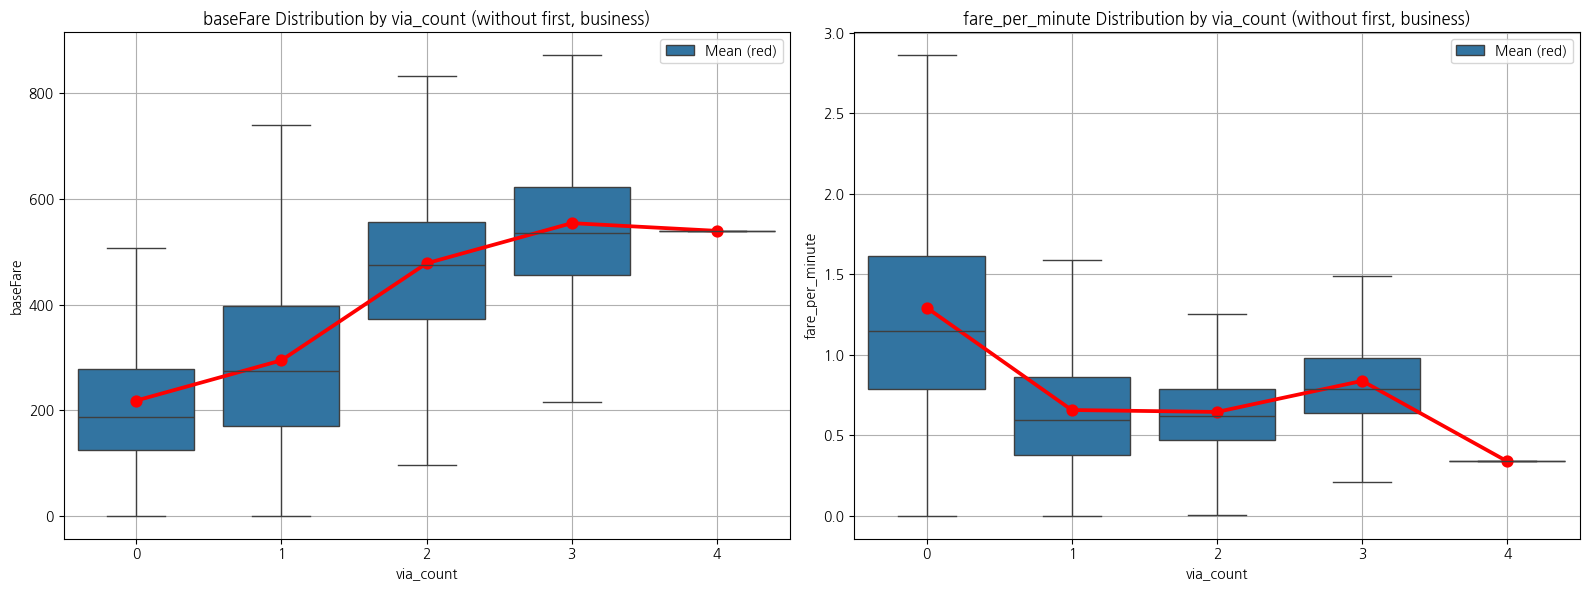

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# 1. baseFare 그래프
sns.boxplot(x='via_count', y='baseFare', data=df, showfliers=False, ax=axes[0])
sns.pointplot(x='via_count', y='baseFare', data=df, color='red', errorbar=None, ax=axes[0])
axes[0].set_title('baseFare Distribution by via_count (without first, business)')
axes[0].set_xlabel('via_count')
axes[0].set_ylabel('baseFare')
axes[0].grid(True)
axes[0].legend(['Mean (red)'])

# 2. fare_per_minute 그래프
sns.boxplot(x='via_count', y='fare_per_minute', data=df, showfliers=False, ax=axes[1])
sns.pointplot(x='via_count', y='fare_per_minute', data=df, color='red', errorbar=None, ax=axes[1])
axes[1].set_title('fare_per_minute Distribution by via_count (without first, business)')
axes[1].set_xlabel('via_count')
axes[1].set_ylabel('fare_per_minute')
axes[1].grid(True)
axes[1].legend(['Mean (red)'])

plt.tight_layout()
plt.show()
#경유횟수 - 총가격 (왼쪽), 경유횟수 - 분당 가격 (오른쪽)  first, business 제거

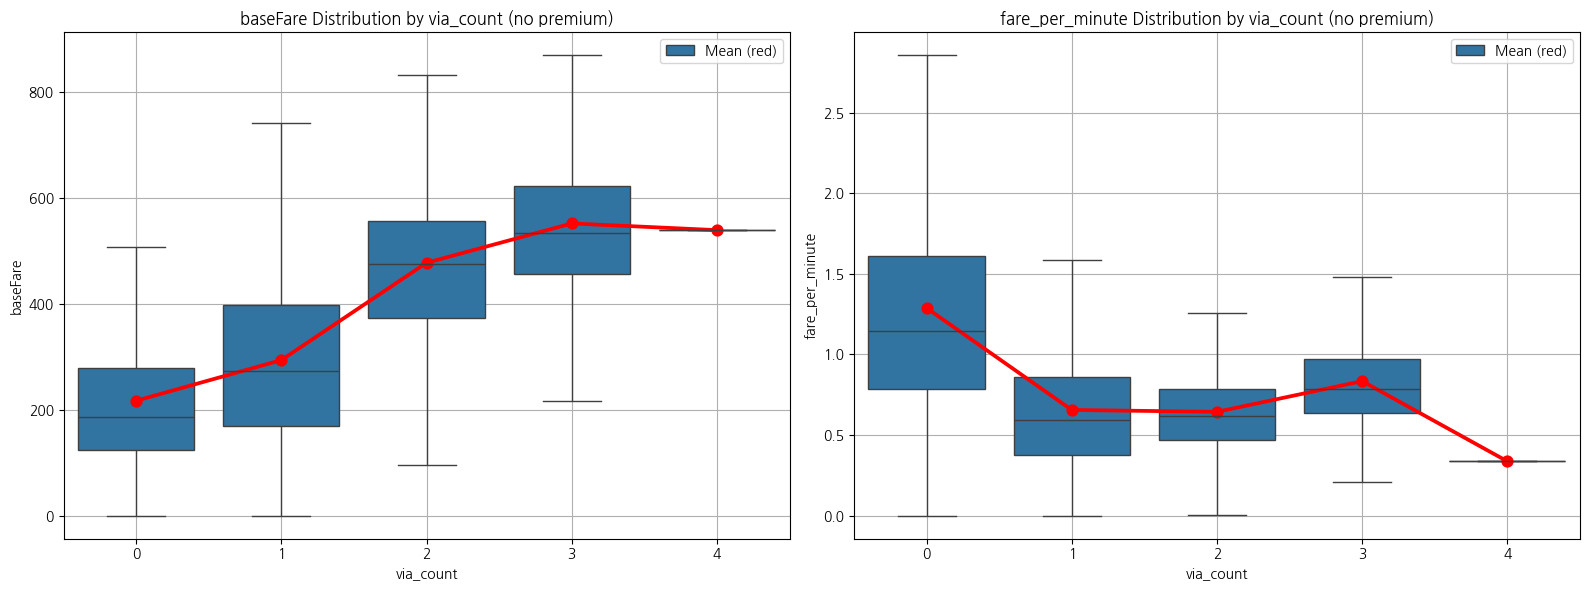

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# 1. baseFare 그래프
sns.boxplot(x='via_count', y='baseFare', data=df_nopremium, showfliers=False, ax=axes[0])
sns.pointplot(x='via_count', y='baseFare', data=df_nopremium, color='red', errorbar=None, ax=axes[0])
axes[0].set_title('baseFare Distribution by via_count (no premium)')
axes[0].set_xlabel('via_count')
axes[0].set_ylabel('baseFare')
axes[0].grid(True)
axes[0].legend(['Mean (red)'])

# 2. fare_per_minute 그래프
sns.boxplot(x='via_count', y='fare_per_minute', data=df_nopremium, showfliers=False, ax=axes[1])
sns.pointplot(x='via_count', y='fare_per_minute', data=df_nopremium, color='red', errorbar=None, ax=axes[1])
axes[1].set_title('fare_per_minute Distribution by via_count (no premium)')
axes[1].set_xlabel('via_count')
axes[1].set_ylabel('fare_per_minute')
axes[1].grid(True)
axes[1].legend(['Mean (red)'])

plt.tight_layout()
plt.show()

#경유횟수 - 총가격 (왼쪽), 경유횟수 - 분당 가격 (오른쪽) first, business, premium 제거

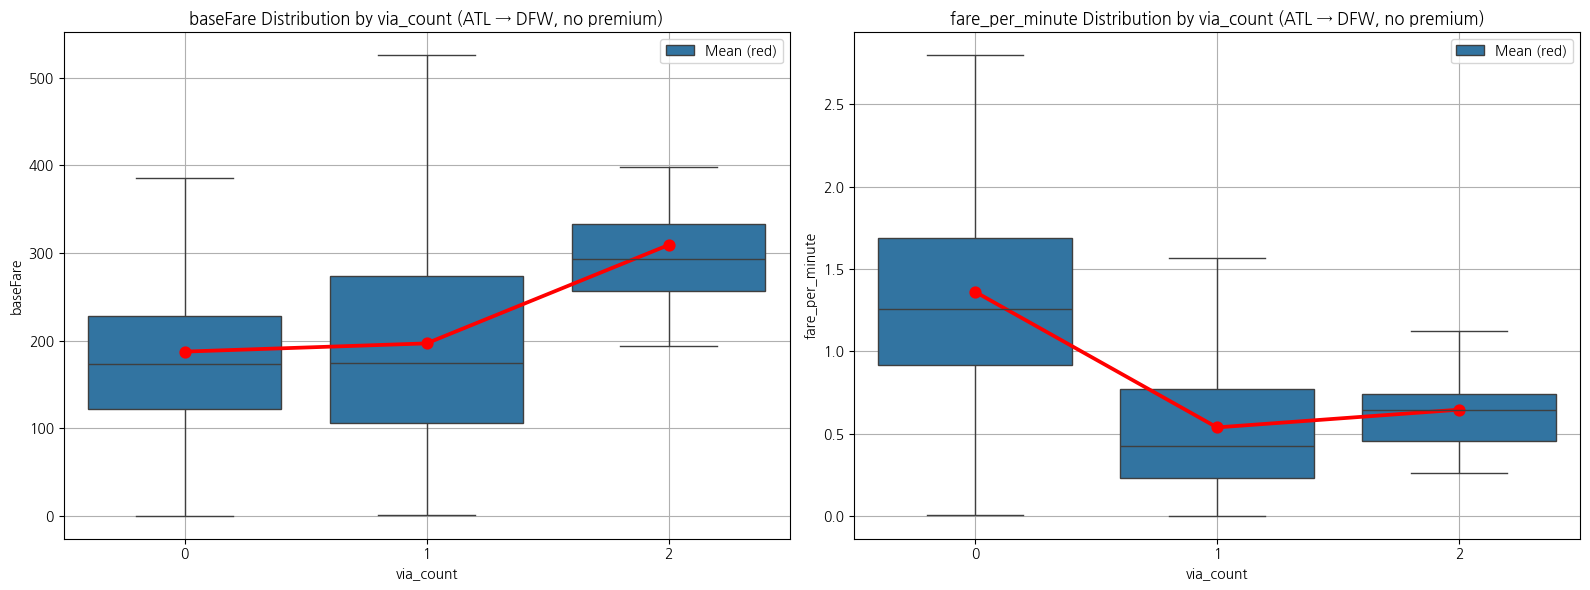

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# 1. baseFare 그래프
sns.boxplot(x='via_count', y='baseFare', data=df_filtered, showfliers=False, ax=axes[0])
sns.pointplot(x='via_count', y='baseFare', data=df_filtered, color='red', errorbar=None, ax=axes[0])
axes[0].set_title('baseFare Distribution by via_count (ATL → DFW, no premium)')
axes[0].set_xlabel('via_count')
axes[0].set_ylabel('baseFare')
axes[0].grid(True)
axes[0].legend(['Mean (red)'])

# 2. fare_per_minute 그래프
sns.boxplot(x='via_count', y='fare_per_minute', data=df_filtered, showfliers=False, ax=axes[1])
sns.pointplot(x='via_count', y='fare_per_minute', data=df_filtered, color='red', errorbar=None, ax=axes[1])
axes[1].set_title('fare_per_minute Distribution by via_count (ATL → DFW, no premium)')
axes[1].set_xlabel('via_count')
axes[1].set_ylabel('fare_per_minute')
axes[1].grid(True)
axes[1].legend(['Mean (red)'])

plt.tight_layout()
plt.show()

#경유횟수 - 총가격 (왼쪽), 경유횟수 - 분당 가격 (오른쪽) first, business, premium 제거, ATL -> DFW 항공권만

In [ ]:
# 날짜 형식으로 변환
df['searchDate'] = pd.to_datetime(df['searchDate'])
df['flightDate'] = pd.to_datetime(df['flightDate'])

df['flightMonth'] = df['flightDate'].dt.month

# 날짜 차이 계산 (비행일까지 며칠 남았는가)
df['daysBeforeFlight'] = (df['flightDate'] - df['searchDate']).dt.days

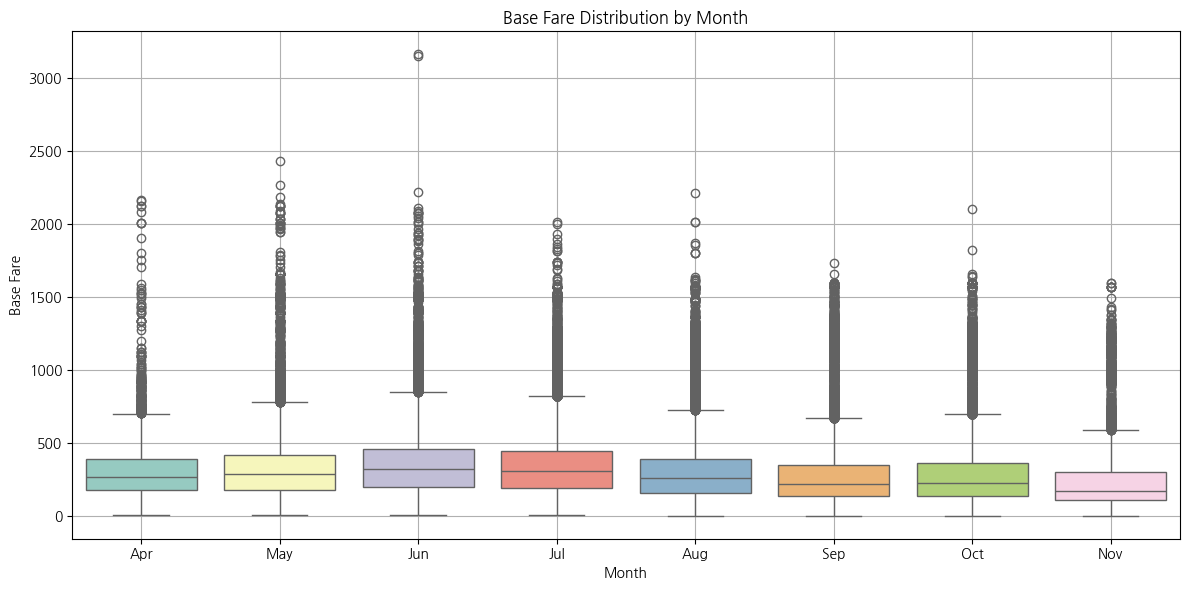

In [ ]:
# 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(x='flightMonth', y='baseFare', data=df, palette='Set3')

# x축 월 이름으로 바꾸기
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(
    ticks=range(len(df['flightMonth'].unique())),
    labels=[month_labels[m-1] for m in sorted(df['flightMonth'].unique())]
)

plt.title('Base Fare Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Base Fare')
plt.grid(True)
plt.tight_layout()
plt.show()

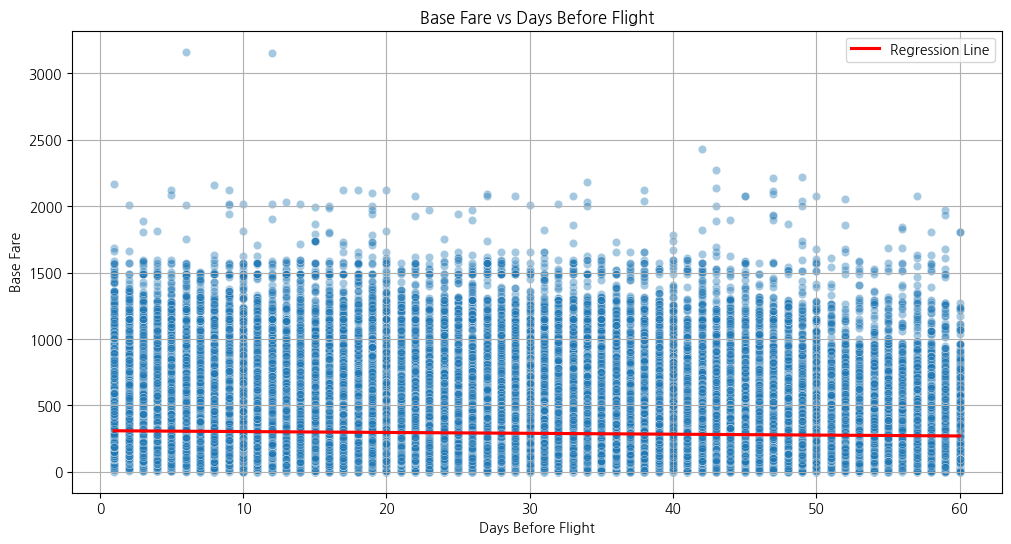

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='daysBeforeFlight', y='baseFare', data=df, alpha=0.4)
sns.regplot(x='daysBeforeFlight', y='baseFare', data=df, scatter=False, color='red', label='Regression Line')

plt.title('Base Fare vs Days Before Flight')
plt.xlabel('Days Before Flight')
plt.ylabel('Base Fare')
plt.legend()
plt.grid(True)
plt.show()


# 4. 무의미하거나 기본적인 EDA

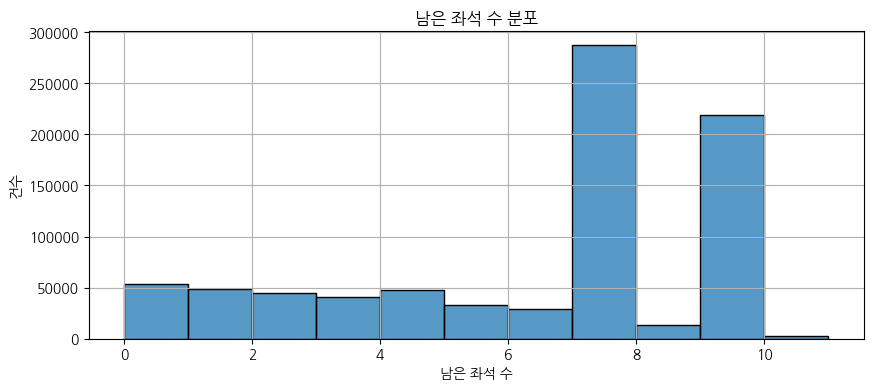

count    820332.000000
mean          5.978204
std           2.880932
min           0.000000
25%           4.000000
50%           7.000000
75%           9.000000
max          10.000000
Name: seatsRemaining, dtype: float64


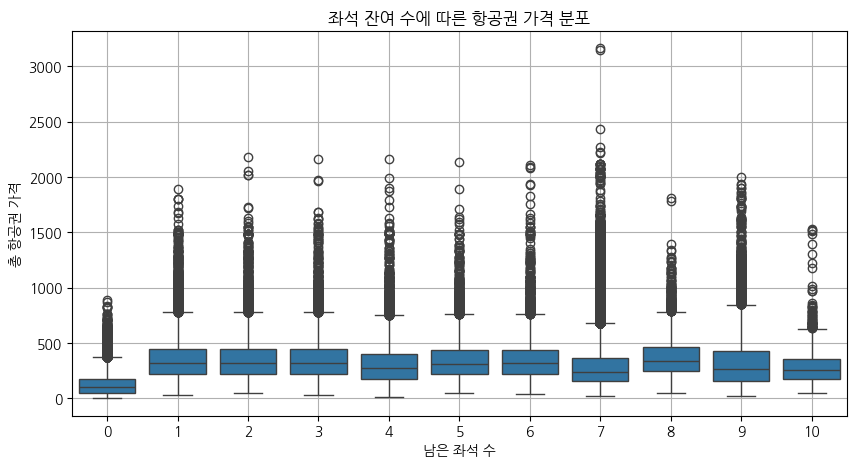

In [ ]:
# 히스토그램으로 분포 시각화
plt.figure(figsize=(10, 4))
sns.histplot(df['seatsRemaining'], bins=range(0, 12), kde=False)
plt.title('남은 좌석 수 분포')
plt.xlabel('남은 좌석 수')
plt.ylabel('건수')
plt.grid(True)
plt.show()

# 기초 통계 확인
print(df['seatsRemaining'].describe())



plt.figure(figsize=(10, 5))
sns.boxplot(x='seatsRemaining', y='baseFare', data=df[df['seatsRemaining'] <= 10])
plt.title('좌석 잔여 수에 따른 항공권 가격 분포')
plt.xlabel('남은 좌석 수')
plt.ylabel('총 항공권 가격')
plt.grid(True)
plt.show()

flightDate 0        2022-05-29
1        2022-04-26
2        2022-06-10
3        2022-06-03
4        2022-04-23
            ...    
821383   2022-11-08
821384   2022-11-11
821385   2022-11-09
821386   2022-11-11
821387   2022-11-06
Name: flightDate, Length: 820332, dtype: datetime64[ns]
flightWeekday 0            Sunday
1           Tuesday
2            Friday
3            Friday
4          Saturday
            ...    
821383      Tuesday
821384       Friday
821385    Wednesday
821386       Friday
821387       Sunday
Name: flightWeekday, Length: 820332, dtype: object


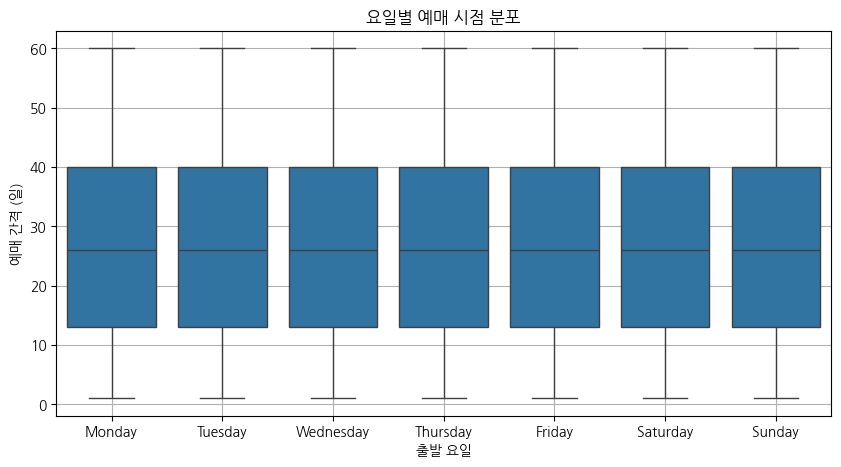

In [ ]:
df['flightDate'] = pd.to_datetime(df['flightDate'])
df['flightWeekday'] = df['flightDate'].dt.day_name()

print ("flightDate",  df['flightDate'])
print ("flightWeekday",  df['flightWeekday'])



plt.figure(figsize=(10, 5))
sns.boxplot(x='flightWeekday', y='days_before_departure', data=df,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('요일별 예매 시점 분포')
plt.xlabel('출발 요일')
plt.ylabel('예매 간격 (일)')
plt.grid(True)
plt.show()

#"일별로 항공권 예매 시점이 다를 것이라는 가설을 세워봤지만,
#통계적으로 유의미한 차이는 발견되지 않았음.
#따라서 요일 정보는 예측 모델에 큰 영향을 주지 않을 수 있으며,
#파생 변수로 포함하더라도 가중치는 낮을 가능성이 클듯."


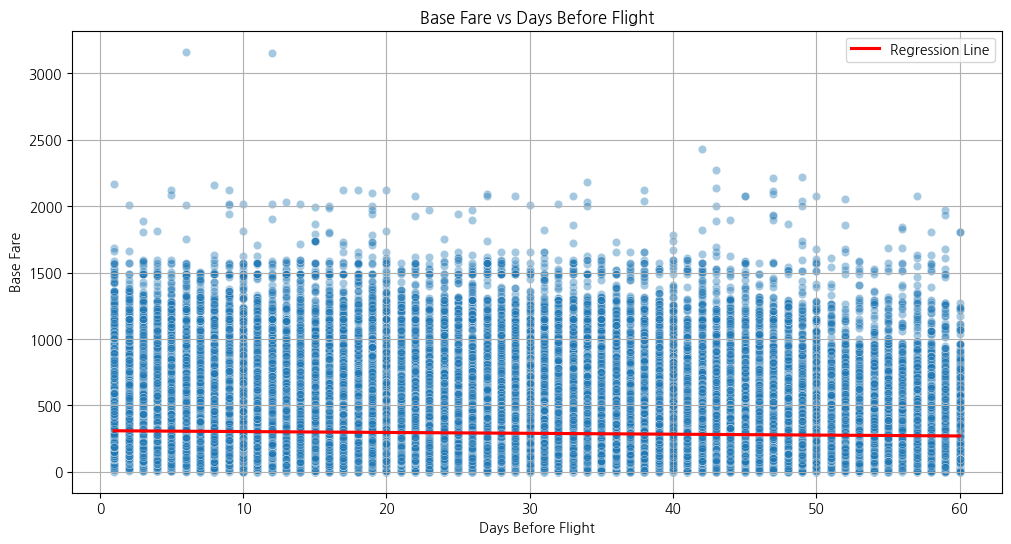

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='daysBeforeFlight', y='baseFare', data=df, alpha=0.4)
sns.regplot(x='daysBeforeFlight', y='baseFare', data=df, scatter=False, color='red', label='Regression Line')

plt.title('Base Fare vs Days Before Flight')
plt.xlabel('Days Before Flight')
plt.ylabel('Base Fare')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df_clean

,searchDate,flightDate,startingAirport,destinationAirport,travelDuration,isBasicEconomy,isNonStop,baseFare,totalFare,seatsRemaining,...,segmentsAirlineName,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode,departure_hour,days_before_departure,flightWeekday,route,hour_bin,cabin_score
0,2022-04-18,2022-05-29,DFW,MIA,PT2H51M,False,True,305.12,342.6,7,...,American Airlines,10260,1115,coach,7,41,6,DFW-MIA,6~12시,1.0
1,2022-04-16,2022-04-26,DFW,ATL,PT2H3M,True,True,110.70,133.6,9,...,Delta,7380,725,coach,8,10,1,DFW-ATL,6~12시,1.0
2,2022-04-17,2022-06-10,LAX,SFO,PT1H24M,False,True,189.77,218.6,7,...,JetBlue Airways,5040,339,coach,17,54,4,LAX-SFO,12~18시,1.0
3,2022-04-17,2022-06-03,DEN,PHL,PT7H14M,False,False,293.95,339.6,9,...,Delta||Delta,6840||9120,693||978,coach||coach,14,47,4,DEN-PHL,12~18시,1.0
4,2022-04-16,2022-04-23,BOS,LAX,PT9H10M,True,False,184.19,221.6,9,...,Delta||Delta,19800||6300,2100||574,coach||coach,6,7,5,BOS-LAX,6~12시,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821383,2022-10-05,2022-11-08,ORD,LGA,PT2H5M,False,True,189.77,218.6,7,...,JetBlue Airways,7500,731,coach,8,34,1,ORD-LGA,6~12시,1.0
821384,2022-10-05,2022-11-11,LGA,IAD,PT1H26M,True,True,124.65,148.6,9,...,United,5160,221,coach,11,37,4,LGA-IAD,6~12시,1.0
821385,2022-10-05,2022-11-09,IAD,LAX,PT9H58M,True,False,125.58,158.6,9,...,United||United,7920||16380,594||1745,coach||coach,8,35,2,IAD-LAX,6~12시,1.0
821386,2022-10-05,2022-11-11,PHL,LAX,PT7H46M,True,False,188.84,226.6,9,...,Delta||Delta,18420||6360,1922||559,coach||coach,18,37,4,PHL-LAX,18~24시,1.0


csv 파일로 저장

In [ ]:
# CSV로 저장
df_clean.to_csv('data_cleaned.csv', index=False)